# Imports/Settings

In [1]:
%load_ext autoreload
%autoreload 2

In [22]:
# 1. Стандартная библиотека
import os
import sys
import warnings
from pathlib import Path
import joblib

# --- ДИНАМИЧЕСКИЙ РАСЧЕТ АБСОЛЮТНЫХ ПУТЕЙ ---
notebook_dir = Path(os.getcwd()).resolve()
if notebook_dir.name == "notebooks":
    PROJECT_ROOT = notebook_dir.parent
else:
    PROJECT_ROOT = notebook_dir

os.chdir(PROJECT_ROOT)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

# 2. Сторонние библиотеки
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 3. Локальные модули
from core.data import UniversalDataLoader
from core.models import get_model
from core.utils import load_hydra_config

# --- РАБОТА С ПРЕДУПРЕЖДЕНИЯМИ ---
warnings.filterwarnings('ignore', category=FutureWarning)

# --- ИНИЦИАЛИЗАЦИЯ HYDRA ---
load_hydra_config.cache_clear()
cfg = load_hydra_config()

reports_dir = Path(cfg.paths.reports_dir)
reports_dir.mkdir(exist_ok=True)

print(f"Проект: {cfg.project_name} | Режим: Error Analysis")

# --- НАСТРОЙКИ ВИЗУАЛИЗАЦИИ ---
try:
    p_cfg = cfg.logging.plots
    plt.style.use(p_cfg.style)
    plt.rcParams.update({
        'figure.figsize': p_cfg.fig_size,
        'figure.dpi': p_cfg.dpi,
        'font.size': p_cfg.font_size,
        'axes.grid': p_cfg.grid,
        'axes.spines.top': p_cfg.spines_top,
        'axes.spines.right': p_cfg.spines_right
    })
    PLOT_ALPHA = p_cfg.alpha
except AttributeError:
    PLOT_ALPHA = 0.5
    print("Используются дефолтные стили Matplotlib.")

Проект: outsource_project_name | Режим: Error Analysis


# Data Loading

In [4]:
loader = UniversalDataLoader(cfg)
df = loader.load_data()
_, val_df, _ = loader.get_splits(df)

target = cfg.data.tabular.target_col
X_val, y_val = val_df.drop(columns=[target]), val_df[target]

print(f"Размер выборки для анализа: {X_val.shape}")

Размер выборки для анализа: (9212, 19)


In [7]:
# --- ЗАГРУЗКА АРТЕФАКТОВ ИЗ ПАПКИ MODELS ---
models_dir = PROJECT_ROOT / cfg.paths.models_dir
model_version = cfg.model.model_version
preprocessor_version = cfg.data.tabular.preprocessing_version
model_name = cfg.model.name

print("Загрузка препроцессора и весов модели...")
prep = joblib.load(models_dir / f"preprocessing_v{preprocessor_version}.pkl")

model = get_model(cfg)
model.load(str(models_dir / f"{model_name}_v{model_version}.cbm"))

Загрузка препроцессора и весов модели...


# Errors Analise

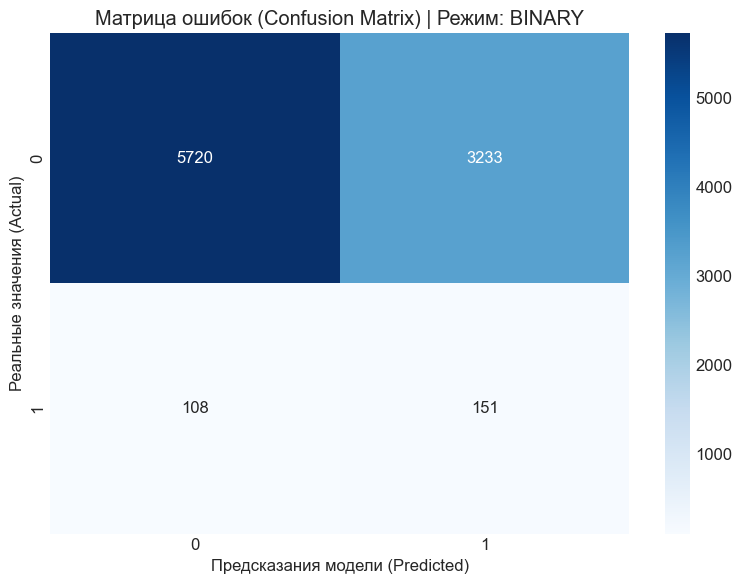

,session_id,client_id,visit_date,visit_time,visit_number,utm_source,utm_medium,utm_campaign,utm_adcontent,utm_keyword,...,device_model,device_screen_resolution,device_browser,geo_country,geo_city,rn,Actual,Predicted,Is_Error,Probability
0,8097518220943185567.1636980383.1636980383,1885350379.1636980383,2021-11-15,15:46:23,1,kjsLglQLzykiRbcDiGcD,cpc,LwJZxKuWmvOhPsaCeRjG,None,fBCsmbCkMTIBLHlRmDIe,...,None,1920x1080,Chrome,Russia,Moscow,1,0,0,0,0.250177
1,3871838522767641935.1631391066.1631391066,901482655.1631392,2021-09-11,23:00:00,1,kjsLglQLzykiRbcDiGcD,cpc,RoDitORHdzGfGhNCyEMy,None,None,...,None,412x915,Chrome,Uzbekistan,Tashkent,1,0,0,0,0.152880
2,8832133571888710756.1631224932.1631224932,2056391344.1631224,2021-09-10,01:00:00,1,fDLlAcSmythWSCVMvqvL,(none),LTuZkdKfxRGVceoWkVyg,JNHcPlZPxEMWDnRiyoBf,None,...,None,375x667,Safari,Russia,Moscow,1,0,1,1,0.590529
3,6924203228058078148.1630311668.1630311668,1612166694.1627638724,2021-08-30,11:00:00,2,MvfHsxITijuriZxsqZqt,cpm,FTjNLDyTrXaWYgZymFkV,PkybGvWbaqORmxjNunqZ,None,...,None,1920x1080,Chrome,Russia,Saint Petersburg,1,0,0,0,0.164339
4,6176025740490865374.1637907166.1637907166,1437968048.1637907166,2021-11-26,09:12:46,1,fDLlAcSmythWSCVMvqvL,(none),LTuZkdKfxRGVceoWkVyg,JNHcPlZPxEMWDnRiyoBf,puhZPIYqKXeFPaUviSjo,...,None,375x812,Safari (in-app),Russia,Moscow,1,0,0,0,0.403358


In [13]:
X_val_clean = prep.transform(X_val)
preds = model.predict(X_val_clean)

task_type = cfg.get('task_type', 'binary') # Безопасно берем из корня конфига

# Создаем базовый датафрейм для анализа
error_df = X_val.copy()
error_df['Actual'] = y_val.values
error_df['Predicted'] = preds

# ============================================================================
# ВЕТКА 1: БИНАРНАЯ ИЛИ МНОГОКЛАССОВАЯ КЛАССИФИКАЦИЯ (Матрица ошибок)
# ============================================================================
if task_type in ['binary', 'multiclass']:
    error_df['Is_Error'] = (error_df['Actual'] != error_df['Predicted']).astype(int)
    
    if hasattr(model, 'predict_proba') and task_type == 'binary':
        error_df['Probability'] = model.predict_proba(X_val_clean)[:, 1]

    # Строим красивую матрицу ошибок (Confusion Matrix)
    cm = confusion_matrix(error_df['Actual'], error_df['Predicted'])
    
    plt.figure(figsize=(8, 6))
    # Если классов много, аннотации автоматически адаптируются
    sns.heatmap(
        cm, 
        annot=True, 
        fmt='d', 
        cmap='Blues', 
        xticklabels=np.unique(error_df['Actual']), 
        yticklabels=np.unique(error_df['Actual'])
    )
    plt.title(f"Матрица ошибок (Confusion Matrix) | Режим: {task_type.upper()}")
    plt.ylabel("Реальные значения (Actual)")
    plt.xlabel("Предсказания модели (Predicted)")
    plt.tight_layout()
    plt.show()

# ============================================================================
# ВЕТКА 2: РЕГРЕССИЯ (Анализ остатков и плотности ошибок)
# ============================================================================
elif task_type == 'regression':
    error_df['Error'] = error_df['Predicted'] - error_df['Actual']
    error_df['AbsError'] = error_df['Error'].abs()
    
    # Строим двухпанельный график анализа распределения ошибок
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # График 1: Scatter plot (Факт vs Предсказание) — идеальный прогноз идет по диагонали
    sns.scatterplot(data=error_df, x='Actual', y='Predicted', alpha=PLOT_ALPHA, ax=axes[0])
    max_val = max(error_df['Actual'].max(), error_df['Predicted'].max())
    min_val = min(error_df['Actual'].min(), error_df['Predicted'].min())
    axes[0].plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='Идеальный прогноз')
    axes[0].set_title("Соотношение: Факт vs Предсказание")
    axes[0].set_ylabel("Предсказано моделью")
    axes[0].set_xlabel("Реальный таргет")
    axes[0].legend()
    
    # График 2: Распределение остатков (Где гуще всего ошибки)
    sns.histplot(data=error_df, x='Error', kde=True, ax=axes[1], color='purple')
    axes[1].axvline(0, color='red', linestyle='--')
    axes[1].set_title("Распределение величины ошибок (Остатки / Residuals)")
    axes[1].set_xlabel("Величина ошибки (Predicted - Actual)")
    axes[1].set_ylabel("Количество строк")
    
    plt.tight_layout()
    plt.show()

# Выводим первые строки для проверки схемы
display(error_df.head())

# Search Trends

C:\Users\Максим\AppData\Local\Temp\ipykernel_6408\4161841043.py:11: DeprecationWarning: Converting `np.inexact` or `np.floating` to a dtype is deprecated. The current result is `float64` which is not strictly correct.
  num_cols = [col for col in error_df.columns if col not in exclude_cols and col not in dropped_by_config and error_df[col].dtype in [np.number, 'int64', 'float64']]


=== ЗАПУСК ПОСТРОЕНИЯ СВОДНОГО ОТЧЕТА ТРЕНДОВ (6 ФИЧЕЙ) ===


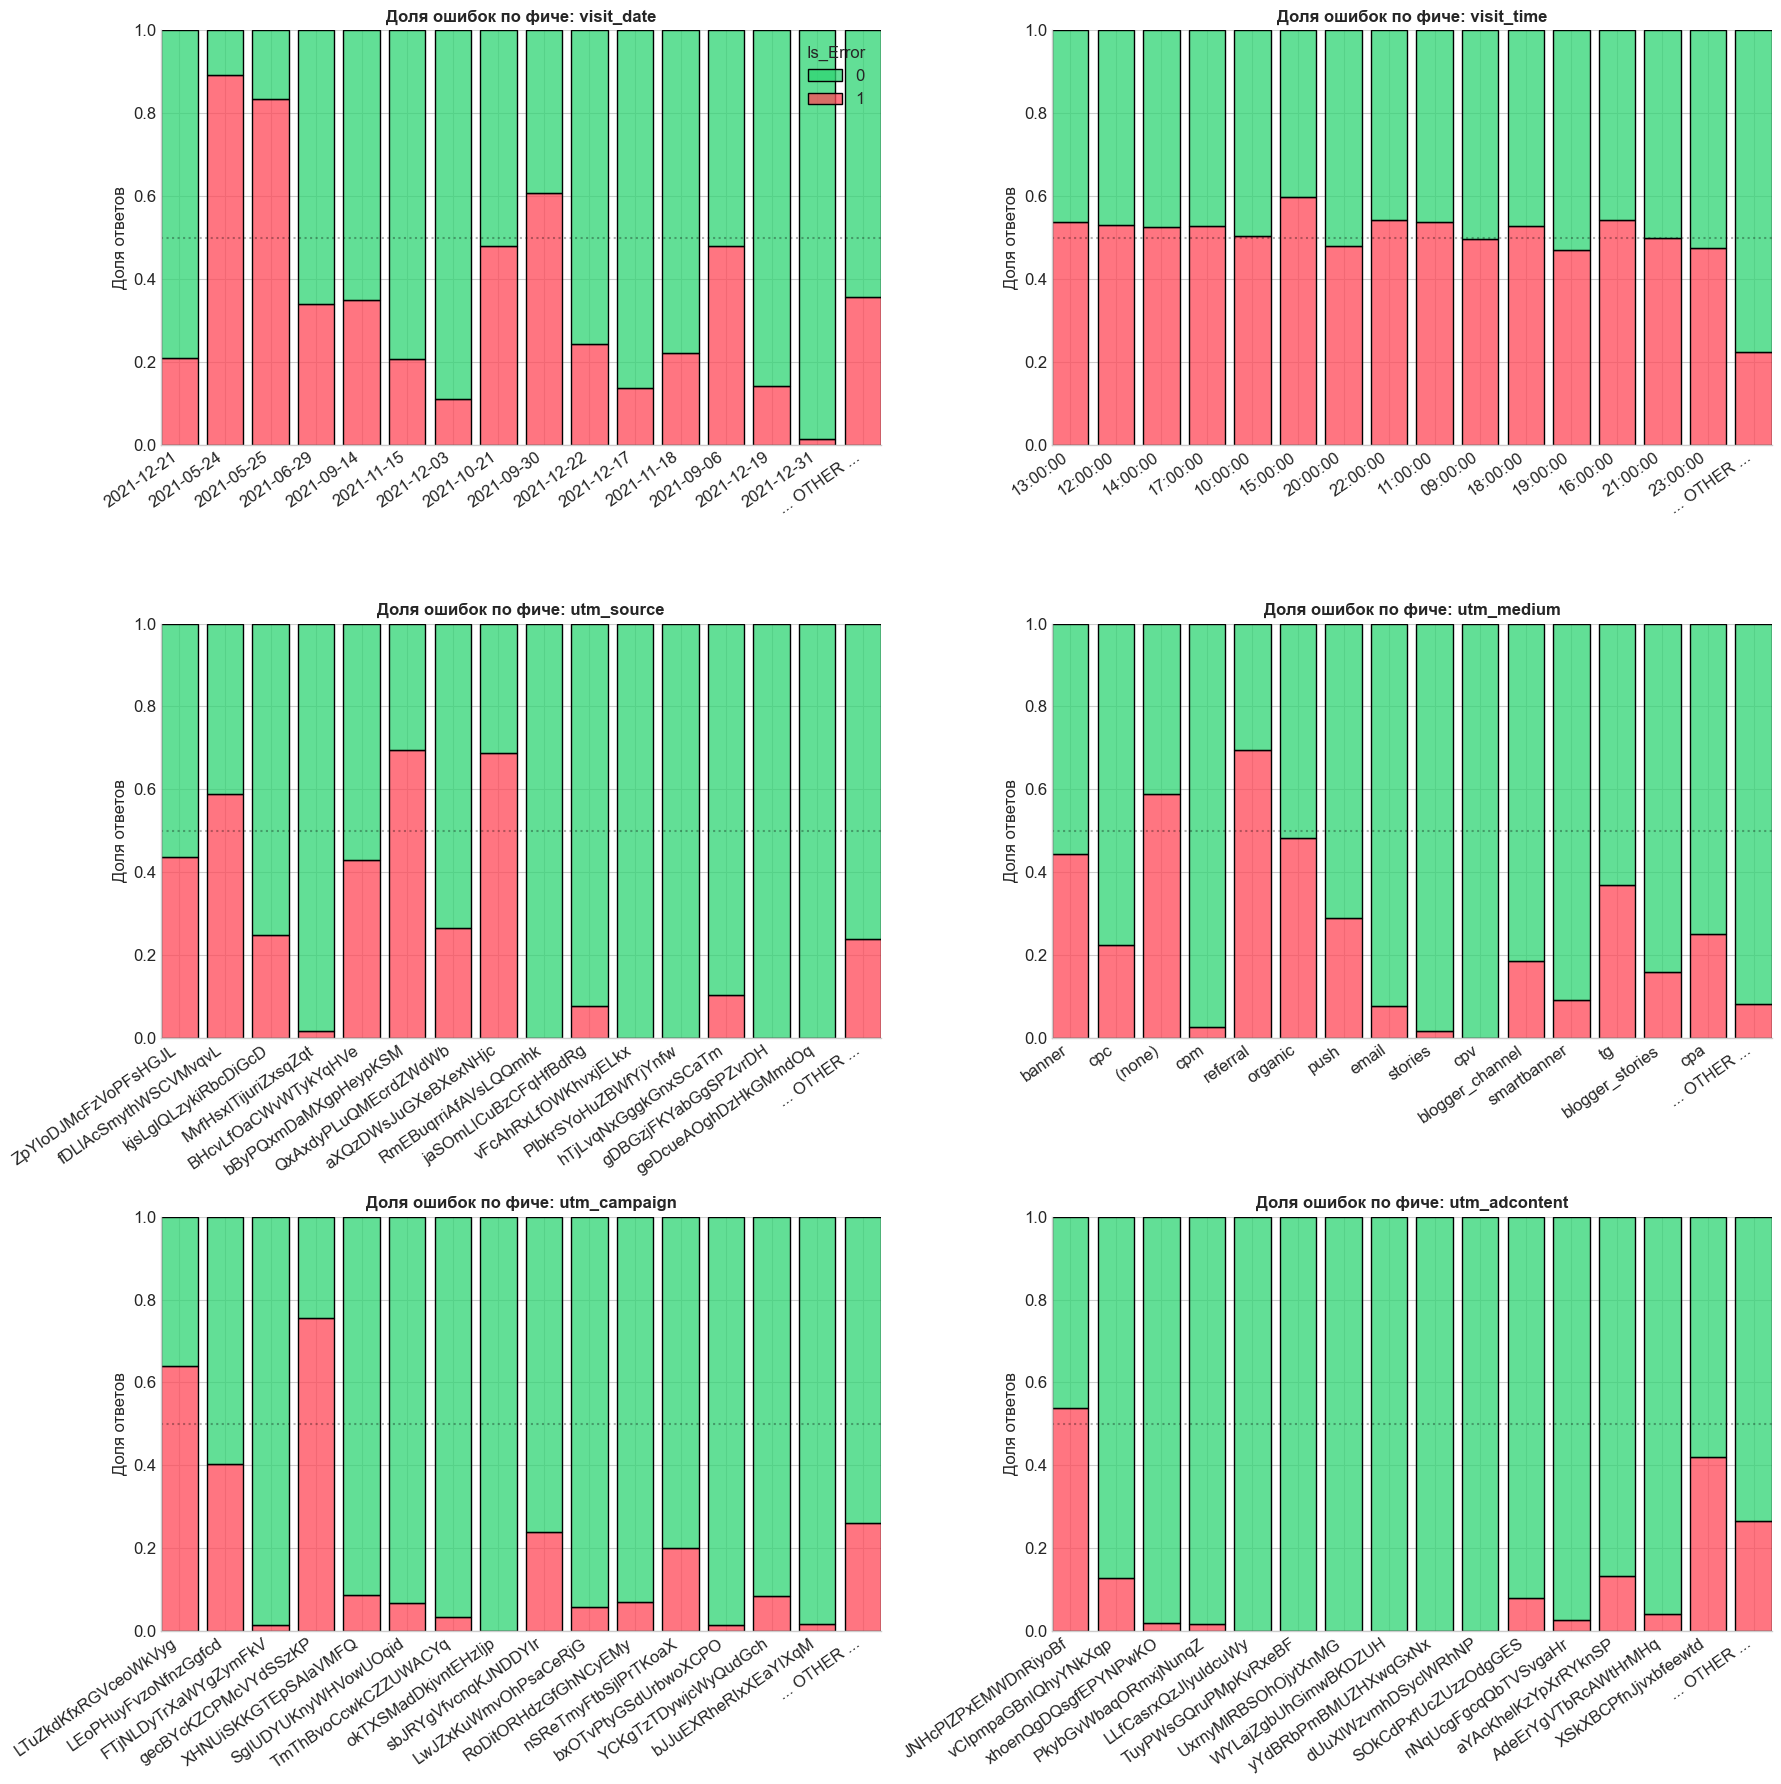

✅ Сводное полотно трендов успешно сохранено в: reports\features_error_trends_v1.0.0.png


In [24]:
# --- НАСТРОЙКИ ФИЛЬТРАЦИИ И ДИРЕКТОРИЙ ---
TOP_N_FEATURES_TO_ANALYZE = 6  # Рекомендую 4-6, чтобы полотно не было гигантским
TOP_K_CATEGORIES_TO_SHOW = 15

# Исключаем служебные метки и задропленные в конфигурации фичи
exclude_cols = ['Actual', 'Predicted', 'Is_Error', 'Probability', 'Prediction_Type', 
                'Error', 'AbsError', 'Confidence_Mistake', 'session_id', 'client_id', 'Is_Worst']
dropped_by_config = list(cfg.data.tabular.get('drop_cols', []))

cat_cols = [col for col in error_df.columns if col not in exclude_cols and col not in dropped_by_config and error_df[col].dtype == 'object']
num_cols = [col for col in error_df.columns if col not in exclude_cols and col not in dropped_by_config and error_df[col].dtype in [np.number, 'int64', 'float64']]

features_to_analyze = cat_cols[:TOP_N_FEATURES_TO_ANALYZE]
n_features = len(features_to_analyze)

if n_features == 0:
    print("Категориальных признаков для анализа не найдено.")
else:
    print(f"=== ЗАПУСК ПОСТРОЕНИЯ СВОДНОГО ОТЧЕТА ТРЕНДОВ ({n_features} ФИЧЕЙ) ===")
    
    # Динамически рассчитываем сетку: 2 графика в ряд
    n_cols = 2
    n_rows = int(np.ceil(n_features / n_cols))
    
    # Создаем ОДНО ОБЩЕЕ ПОЛОТНО
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 6 * n_rows))
    axes = axes.flatten() # Делаем массив одномерным для удобства итерации

    # ============================================================================
    # ВЕТКА КЛАССИФИКАЦИИ
    # ============================================================================
    if task_type in ['binary', 'multiclass']:
        error_df['Is_Error'] = (error_df['Actual'] != error_df['Predicted']).astype(int)
        error_rates = {}
        
        for i, col in enumerate(features_to_analyze):
            top_categories = error_df[col].value_counts().index[:TOP_K_CATEGORIES_TO_SHOW]
            
            plot_df = error_df.copy()
            plot_df[col] = plot_df[col].apply(lambda x: x if x in top_categories else '... OTHER ...')
            plot_order = list(top_categories) + ['... OTHER ...'] if '... OTHER ...' in plot_df[col].values else list(top_categories)
            plot_df[col] = pd.Categorical(plot_df[col], categories=plot_order, ordered=True)
            
            # Считаем точные рейты ошибок для аннотаций
            col_error_rates = error_df.groupby(col)['Is_Error'].mean() * 100
            
            # Рисуем на конкретном сабплоте сетки
            sns.histplot(
                data=plot_df, x=col, hue='Is_Error', multiple='fill', 
                shrink=0.8, palette={0: '#2ed573', 1: '#ff4757'}, ax=axes[i], legend=True if i == 0 else False
            )
            
            # Добавляем текстовые подписи процента ошибок прямо НАД каждым столбцом
            axes[i].set_title(f"Доля ошибок по фиче: {col}", fontsize=12, fontweight='bold')
            axes[i].set_ylabel("Доля ответов")
            axes[i].set_xlabel("")
            axes[i].axhline(0.5, color='black', linestyle=':', alpha=0.3)
            axes[i].tick_params(axis='x', rotation=35)
            
            # Специфический сдвиг подписей для выравнивания
            for tick in axes[i].get_xticklabels():
                tick.set_horizontalalignment('right')

    # ============================================================================
    # ВЕТКА РЕГРЕССИИ
    # ============================================================================
    elif task_type == 'regression':
        for i, col in enumerate(features_to_analyze):
            top_categories = error_df[col].value_counts().index[:TOP_K_CATEGORIES_TO_SHOW]
            
            plot_df = error_df.copy()
            plot_df[col] = plot_df[col].apply(lambda x: x if x in top_categories else '... OTHER ...')
            plot_order = list(top_categories) + ['... OTHER ...'] if '... OTHER ...' in plot_df[col].values else list(top_categories)
            plot_df[col] = pd.Categorical(plot_df[col], categories=plot_order, ordered=True)
            
            # Строим Boxplot
            sns.boxplot(
                data=plot_df, x=col, y='Error', order=plot_order, palette='coolwarm', ax=axes[i]
            )
            
            axes[i].axhline(0, color='red', linestyle='--', linewidth=1.2)
            axes[i].set_title(f"Разброс ошибок (Residuals) по фиче: {col}", fontsize=12, fontweight='bold')
            axes[i].set_ylabel("Ошибка (Predicted - Actual)")
            axes[i].set_xlabel("")
            axes[i].tick_params(axis='x', rotation=35)
            for tick in axes[i].get_xticklabels():
                tick.set_horizontalalignment('right')

    # Прячем неиспользованные ячейки в сетке графиков, если фичей нечетное количество
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    # Наводим красоту и сохраняем всё полотно целиком
    plt.tight_layout()
    output_plot_path = reports_dir / f"features_error_trends_v{cfg.data.tabular.preprocessing_version}.png"
    plt.savefig(output_plot_path, dpi=150, bbox_inches='tight')
    plt.show()
    
    print(f"✅ Сводное полотно трендов успешно сохранено в: {output_plot_path}")

# Worst Preds

=== ЗАПУСК ЛОКАЛЬНОГО АНАЛИЗА ОШИБОК | РЕЖИМ: BINARY ===


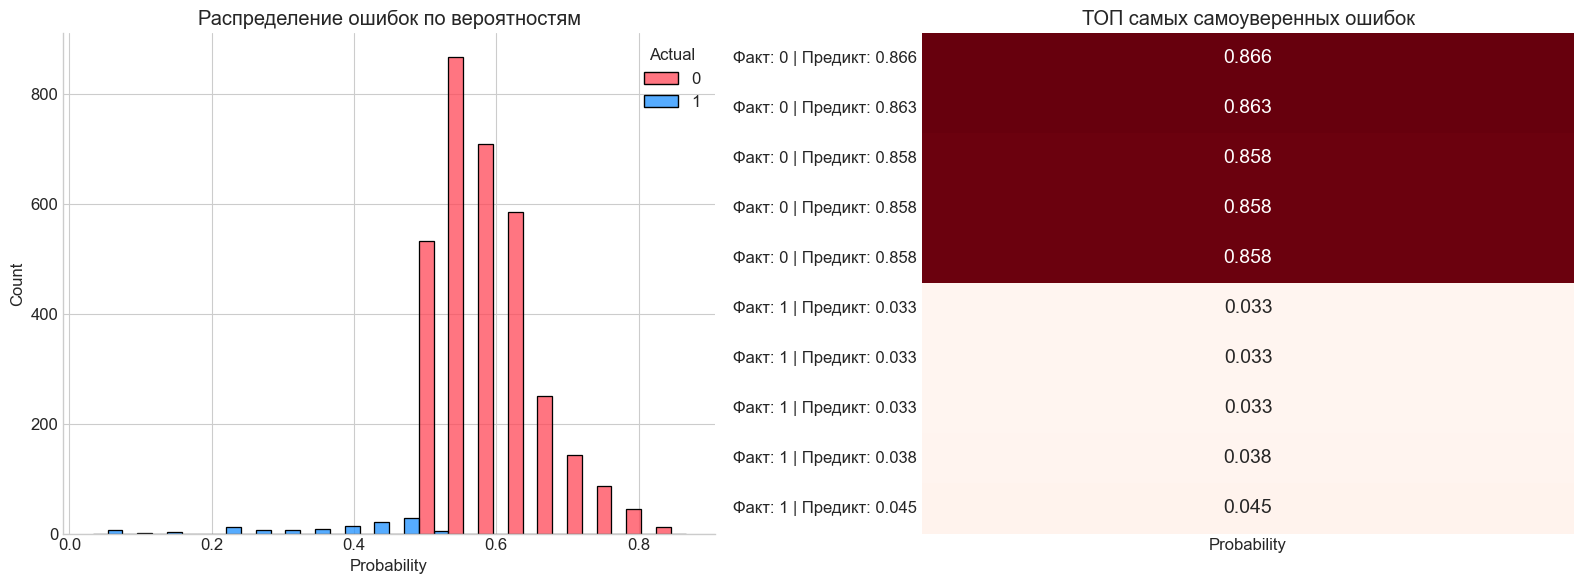

=== ОТЧЕТ ПО ХУДШИМ ОШИБКАМ КЛАССИФИКАЦИИ ===
Версия фичей: 1.1.0 | Версия препроцессинга: 1.0.0

🔥 ТОП-5 FALSE POSITIVE (Модель уверенно ждала конверсию, но её не было):
  • Строка [ID 6942] | Вероятность модели: 0.866
    - visit_date: 2021-05-25
    - visit_time: 12:00:00
    - visit_number: 6
    - utm_source: bByPQxmDaMXgpHeypKSM
    - utm_medium: referral
  ---------------------------------------------
  • Строка [ID 544] | Вероятность модели: 0.863
    - visit_date: 2021-07-15
    - visit_time: 13:00:00
    - visit_number: 21
    - utm_source: bByPQxmDaMXgpHeypKSM
    - utm_medium: referral
  ---------------------------------------------
  • Строка [ID 8077] | Вероятность модели: 0.858
    - visit_date: 2021-12-15
    - visit_time: 08:22:48
    - visit_number: 1
    - utm_source: QxAxdyPLuQMEcrdZWdWb
    - utm_medium: cpc
  ---------------------------------------------
  • Строка [ID 1370] | Вероятность модели: 0.858
    - visit_date: 2021-12-19
    - visit_time: 00:40:15
    - 

In [23]:
# Ограничиваем количество выводимых фичей, чтобы отчёт был читаемым
TOP_FEATURES_COUNT = 5

print(f"=== ЗАПУСК ЛОКАЛЬНОГО АНАЛИЗА ОШИБОК | РЕЖИМ: {task_type.upper()} ===")

# Автоматически определяем доступные реальные фичи (исключаем служебные метки и дропы)
internal_cols = ['Actual', 'Predicted', 'Is_Error', 'Probability', 'Confidence_Mistake', 'Prediction_Type', 'Is_Worst']
dropped_by_config = list(cfg.data.tabular.get('drop_cols', []))
available_features = [col for col in error_df.columns if col not in internal_cols and col not in dropped_by_config]
features_to_print = available_features[:TOP_FEATURES_COUNT]

# Инициализируем переменные путей, чтобы они гарантированно существовали при сохранении
plot_path = reports_dir / f"worst_errors_plots_v{cfg.data.tabular.preprocessing_version}.png"
text_path = reports_dir / f"worst_errors_profile_v{cfg.data.tabular.preprocessing_version}.txt"

# ============================================================================
# СЦЕНАРИЙ 1: БИНАРНАЯ И МНОГОКЛАССОВАЯ КЛАССИФИКАЦИЯ
# ============================================================================
if task_type in ['binary', 'multiclass']:
    if 'Probability' in error_df.columns and task_type == 'binary':
        error_df['Confidence_Mistake'] = np.where(
            error_df['Actual'] == 1, 1 - error_df['Probability'], error_df['Probability']      
        )
        
        # 1. Строим "простыню" из двух графиков классификации
        fig, axes = plt.subplots(1, 2, figsize=(16, 6))
        
        sns.histplot(data=error_df[error_df['Is_Error'] == 1], x='Probability', 
                     hue='Actual', multiple='dodge', bins=20, ax=axes[0], palette={0: '#ff4757', 1: '#1e90ff'})
        axes[0].set_title("Распределение ошибок по вероятностям")
        
        worst_fp = error_df[(error_df['Actual'] == 0) & (error_df['Is_Error'] == 1)].sort_values(by='Probability', ascending=False).head(5)
        worst_fn = error_df[(error_df['Actual'] == 1) & (error_df['Is_Error'] == 1)].sort_values(by='Probability', ascending=True).head(5)
        worst_cases = pd.concat([worst_fp, worst_fn])
        
        worst_plot_data = worst_cases[['Actual', 'Probability']].copy()
        worst_plot_data['Label'] = [f"Факт: {int(a)} | Предикт: {p:.3f}" for a, p in zip(worst_plot_data['Actual'], worst_plot_data['Probability'])]
        worst_plot_data = worst_plot_data.set_index('Label')
        
        sns.heatmap(worst_cases[['Probability']], annot=True, cmap='Reds', cbar=False, fmt='.3f', ax=axes[1], annot_kws={"size": 14})
        axes[1].set_title("ТОП самых самоуверенных ошибок")
        axes[1].set_yticklabels(worst_plot_data.index, rotation=0)
        
        plt.tight_layout()
        plt.savefig(plot_path, dpi=150, bbox_inches='tight')
        plt.show()

        # 2. Формируем текстовый профиль для классификации
        report_text = f"=== ОТЧЕТ ПО ХУДШИМ ОШИБКАМ КЛАССИФИКАЦИИ ===\n"
        report_text += f"Версия фичей: {cfg.data.tabular.features_version} | Версия препроцессинга: {cfg.data.tabular.preprocessing_version}\n"
        report_text += "="*70 + "\n\n"
        
        report_text += "🔥 ТОП-5 FALSE POSITIVE (Модель уверенно ждала конверсию, но её не было):\n"
        for idx, row in worst_fp.iterrows():
            report_text += f"  • Строка [ID {idx}] | Вероятность модели: {row['Probability']:.3f}\n"
            for f in features_to_print:
                report_text += f"    - {f}: {row[f]}\n"
            report_text += "  " + "-"*45 + "\n"
            
        report_text += "\n❄️ ТОП-5 FALSE NEGATIVE (Конверсия была, но модель её полностью пропустила):\n"
        for idx, row in worst_fn.iterrows():
            report_text += f"  • Строка [ID {idx}] | Вероятность модели: {row['Probability']:.3f}\n"
            for f in features_to_print:
                report_text += f"    - {f}: {row[f]}\n"
            report_text += "  " + "-"*45 + "\n"
    else:
        # Если это многокласс или нет вероятностей
        worst_cases = error_df[error_df['Is_Error'] == 1].head(10)
        report_text = "=== ТОП-10 ОШИБОК КЛАССИФИКАЦИИ (БЕЗ ВЕРОЯТНОСТЕЙ) ===\n"
        for idx, row in worst_cases.iterrows():
            report_text += f"  • Строка [ID {idx}] | Факт: {row['Actual']} | Предикт: {row['Predicted']}\n"
            for f in features_to_print:
                report_text += f"    - {f}: {row[f]}\n"
            report_text += "  " + "-"*45 + "\n"

# ============================================================================
# СЦЕНАРИЙ 2: РЕГРЕССИЯ
# ============================================================================
elif task_type == 'regression':
    worst_indices = error_df.sort_values(by='AbsError', ascending=False).head(10).index
    error_df['Is_Worst'] = error_df.index.isin(worst_indices).astype(int)
    
    # 1. Строим "простыню" из двух графиков регрессии
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    
    sns.scatterplot(data=error_df, x='Actual', y='Predicted', hue='Is_Worst', 
                    palette={0: '#747d8c', 1: '#ff4757'}, alpha=0.7, ax=axes[0])
    axes[0].set_title("Точки максимального крушения модели")
    
    worst_cases = error_df.loc[worst_indices].copy()
    worst_cases['Index_Str'] = worst_cases.index.astype(str)
    
    sns.barplot(data=worst_cases, x='Error', y='Index_Str', ax=axes[1], palette='vlag')
    axes[1].axvline(0, color='black', linestyle='--')
    axes[1].set_title("Величина отклонения в ТОП-10 худших прогнозах")
    
    plt.tight_layout()
    plt.savefig(plot_path, dpi=150, bbox_inches='tight')
    plt.show()

    # 2. Формируем текстовый профиль для регрессии
    report_text = f"=== ОТЧЕТ ПО КАТАСТРОФИЧЕСКИМ ВЫБРОСАМ РЕГРЕССИИ ===\n"
    report_text += f"Версия фичей: {cfg.data.tabular.features_version} | Версия препроцессинга: {cfg.data.tabular.preprocessing_version}\n"
    report_text += "="*70 + "\n\n"
    
    report_text += "🚨 ТОП-10 ХУДШИХ ПРОГНОЗОВ (Где модель промахнулась сильнее всего):\n"
    for idx, row in worst_cases.iterrows():
        report_text += f"  • Строка [ID {idx}] | Реально: {row['Actual']:.2f} | Предсказано: {row['Predicted']:.2f} | Ошибка: {row['Error']:.2f}\n"
        for f in features_to_print:
            report_text += f"    - {f}: {row[f]}\n"
        report_text += "  " + "-"*45 + "\n"

# ============================================================================
# ФИНАЛЬНЫЙ ВЫВОД И ЛОКАЛЬНОЕ СОХРАНЕНИЕ
# ============================================================================
# Печатаем карточки прямо в консоль ноутбука для удобного чтения
print(report_text)

# Сохраняем текстовый файл в локальную директорию reports/
with open(text_path, "w", encoding="utf-8") as f:
    f.write(report_text)

print(f"✅ Локальные отчеты успешно сгенерированы и сохранены:")
print(f"   - Графики сохранены в: {plot_path}")
print(f"   - Текстовое досье сохранено в: {text_path}")